### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Load Dataset

In [2]:
df = pd.read_csv("cleaned_customer_financial_behaviour.csv")

### Display first few rows

In [3]:
print(df.head())

   age  gender  employment_status  annual_income  monthly_income  loan_amount  \
0   42       1                  1        83834.0         6986.17      50000.0   
1   35       0                  0        56472.0         4706.00      50000.0   
2   44       1                  0       165696.0        13808.00      50000.0   
3   41       0                  0        79943.0         6661.92      50000.0   
4   28       0                  0       160442.0        13370.17      52071.0   

   interest_rate  loan_term      emi   dti  credit_score_origination  \
0          12.33         36  1668.61  0.35                       720   
1          10.98         48  1291.79  0.41                       658   
2           9.71         84   822.59  0.44                       801   
3          14.42         36  1719.10  0.38                       743   
4          10.81         36  1700.06  0.10                       662   

   revolving_utilization_origination  credit_inquiries_12m  \
0                 

### Prepare Features

In [4]:
X = df.drop("default_12m", axis=1)

### Standardize Features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Elbow Method

In [6]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

### Plot Elbow Curve

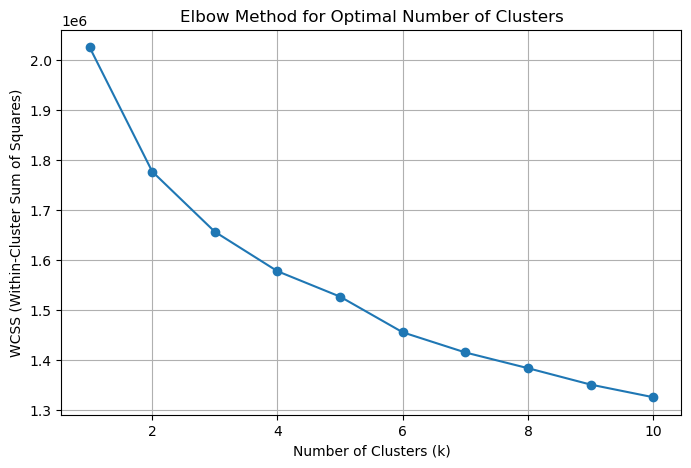

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()

### Silhouette Scores

In [8]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

    print(f"k = {k}: Silhouette Score = {score:.4f}")

k = 2: Silhouette Score = 0.3050
k = 3: Silhouette Score = 0.0815
k = 4: Silhouette Score = 0.0783
k = 5: Silhouette Score = 0.0672
k = 6: Silhouette Score = 0.0761
k = 7: Silhouette Score = 0.0680
k = 8: Silhouette Score = 0.0662
k = 9: Silhouette Score = 0.0698
k = 10: Silhouette Score = 0.0703


### Select Best k

In [9]:
best_k = silhouette_scores.index(max(silhouette_scores)) + 2

print("\nOptimal Number of Clusters (based on Silhouette Score):", best_k)


Optimal Number of Clusters (based on Silhouette Score): 2


### Train Final K-Means Model

In [10]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

### Add cluster labels to dataset

In [11]:
df["Cluster"] = clusters

### Display cluster sizes

In [12]:
print("\nCluster Distribution:")
print(df["Cluster"].value_counts())


Cluster Distribution:
Cluster
0    123486
1     11514
Name: count, dtype: int64


### Display first few rows with cluster labels

In [13]:
print("\nDataset with Cluster Labels:")
print(df.head())


Dataset with Cluster Labels:
   age  gender  employment_status  annual_income  monthly_income  loan_amount  \
0   42       1                  1        83834.0         6986.17      50000.0   
1   35       0                  0        56472.0         4706.00      50000.0   
2   44       1                  0       165696.0        13808.00      50000.0   
3   41       0                  0        79943.0         6661.92      50000.0   
4   28       0                  0       160442.0        13370.17      52071.0   

   interest_rate  loan_term      emi   dti  credit_score_origination  \
0          12.33         36  1668.61  0.35                       720   
1          10.98         48  1291.79  0.41                       658   
2           9.71         84   822.59  0.44                       801   
3          14.42         36  1719.10  0.38                       743   
4          10.81         36  1700.06  0.10                       662   

   revolving_utilization_origination  credit_inqui

### Final Silhouette Score

In [14]:
final_score = silhouette_score(X_scaled, clusters)

print("\nFinal Silhouette Score:", round(final_score, 4))


Final Silhouette Score: 0.305
